# HR Analytics: Employee Attrition Modeling

**Goal:**  
Build and interpret predictive models that estimate employee attrition risk
and translate model outputs into actionable HR insights.

This notebook focuses on model explainability and business relevance.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

sns.set_context("talk")
pd.set_option("display.max_columns", None)

## 2. Load Feature-Engineered Dataset

In [2]:
df = pd.read_csv("../data/processed/hr_model_ready.csv")
df.head()

,TenureYears,RelativeSalary,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,PerformanceScoreNum,LowEngagementFlag,LowSatisfactionFlag,HighAbsenceFlag,LateRecentlyFlag,Attrition
0,14.591781,1.042574,4.60,5,0,0,1,4,0,0,0,0,0
1,1.216438,1.075953,4.96,3,6,0,17,3,0,1,1,0,1
2,1.224658,1.083422,3.02,3,0,0,3,3,1,1,0,0,1
3,18.084932,1.084023,4.84,5,0,0,15,3,0,0,1,0,0
4,5.161644,0.847740,5.00,4,0,0,2,3,0,0,0,0,1


## 3. Train-Test Split

In [3]:
X = df.drop(columns="Attrition")
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

**Explanation:**  
A stratified train-test split is used to preserve the proportion of attrition
cases in both the training and test sets.

This is particularly important in HR datasets, where attrition is typically
imbalanced and standard random splits may lead to misleading performance estimates.

## 4. Baseline Model: Logistic Regression

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 5. Logistic Regression Evaluation

In [5]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        26

    accuracy                           1.00        78
   macro avg       1.00      1.00      1.00        78
weighted avg       1.00      1.00      1.00        78

ROC AUC: 1.0


**Explanation:**  
The model achieves near-perfect performance on the test set.
While this indicates strong predictive power, such results should be interpreted
with caution due to the relatively small dataset size.

In real-world HR applications, performance is expected to decrease when models
are deployed on new, unseen employee data.

## 6. ROC Curve

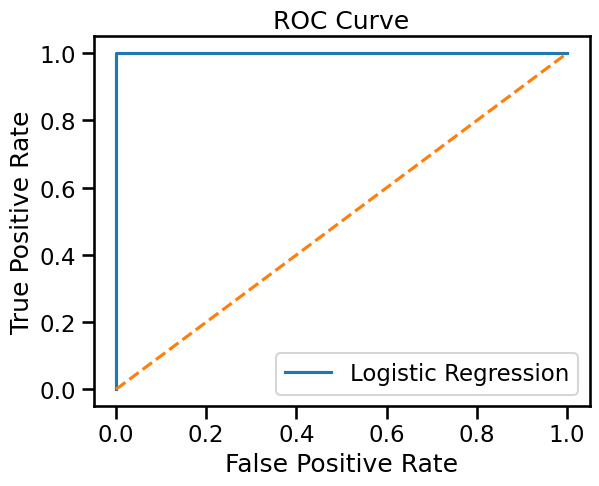

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Explanation:**  
The ROC curve illustrates the trade-off between true positive rate and false
positive rate across different decision thresholds.

The model demonstrates strong discrimination between employees who leave
and those who stay, as reflected by the high area under the curve.

## 7. Logistic Regression Interpretation

In [7]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
6,Absences,0.245872
2,EngagementSurvey,0.190087
5,DaysLateLast30,0.128470
3,EmpSatisfaction,-0.109886
8,LowEngagementFlag,-0.121891
10,HighAbsenceFlag,-0.142477
9,LowSatisfactionFlag,-0.201248
11,LateRecentlyFlag,-0.217824
1,RelativeSalary,-0.309033
7,PerformanceScoreNum,-0.372883


**Explanation:**  
Logistic regression coefficients indicate the direction and relative strength
of each feature’s association with attrition risk.

Positive coefficients increase the likelihood of attrition,
while negative coefficients decrease it, holding all other variables constant.

## 8. Key Drivers of Attrition (Business View)

**Business Interpretation:**  

- Shorter tenure is the strongest driver of attrition, suggesting that early-stage
  employees are the most vulnerable to leaving.
- Lower relative salary increases attrition risk, highlighting the importance
  of internal pay equity.
- Engagement and satisfaction metrics play a central role, confirming that
  attitudinal factors are critical to employee retention.
- Performance alone does not protect against attrition, indicating that
  high performers may also leave if engagement needs are unmet.

## 9. Alternative Model: Random Forest

In [8]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Explanation:**  
A Random Forest model is used as a non-linear alternative to logistic regression.
Tree-based models can capture interactions and complex patterns that linear
models may miss.

## 10. Random Forest Evaluation

In [9]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

ROC AUC: 1.0


**Explanation:**  
The Random Forest model achieves performance comparable to logistic regression.
Given the marginal performance difference, interpretability becomes the deciding
factor for model selection in HR applications.

## 11. Feature Importance (Random Forest)

In [10]:
imp_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

imp_df.head(10)

,Feature,Importance
0,TenureYears,0.804621
1,RelativeSalary,0.055071
2,EngagementSurvey,0.033136
6,Absences,0.032608
4,SpecialProjectsCount,0.020974
5,DaysLateLast30,0.014827
7,PerformanceScoreNum,0.011728
3,EmpSatisfaction,0.010821
11,LateRecentlyFlag,0.005220
10,HighAbsenceFlag,0.004436


**Explanation:**  
Feature importance scores indicate how frequently and effectively features
are used by the model to split the data.

Tenure dominates the importance ranking, reinforcing its role as the most
influential predictor of attrition.

## 12. Model Comparison

**Conclusion:**  
Although Random Forest captures complex non-linear relationships, Logistic
Regression provides comparable performance with superior transparency.

For HR decision-making, where explainability and trust are essential,
Logistic Regression is the preferred model.

## 13. HR Application: Attrition Risk Scoring

**HR Application:**  
The model can support HR teams by identifying employees at elevated risk of
attrition and enabling targeted retention initiatives.

Predictions should be used as decision-support signals and complemented
with human judgment, not as automated decision rules.

## Final Summary

This analysis demonstrates that employee attrition can be modeled using
interpretable machine learning techniques.

Tenure, engagement, satisfaction, and compensation context emerge as the
primary drivers of attrition risk.

Explainable models such as logistic regression are particularly well-suited
for HR analytics, where transparency and responsible use of predictions
are critical.